In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.optimize._linesearch import line_search_wolfe2  
import jax.numpy as jnp # this is a thin wrapper to NumPy within JAX
from jax import grad, hessian

In [2]:
# ----------------------------
# Branin–Hoo (2D) definition
# ----------------------------
def branin(x):
    x1, x2 = float(x[0]), float(x[1])
    a = 1.0
    b = 5.1 / (4.0 * np.pi**2)
    c = 5.0 / np.pi
    r = 6.0
    s = 10.0
    t = 1.0 / (8.0 * np.pi)
    u = x2 - b * x1**2 + c * x1 - r
    return a * u**2 + s * (1.0 - t) * np.cos(x1) + s

def branin_grad(x):
    x1, x2 = float(x[0]), float(x[1])
    b = 5.1 / (4.0 * np.pi**2)
    c = 5.0 / np.pi
    r = 6.0
    s = 10.0
    t = 1.0 / (8.0 * np.pi)
    u = x2 - b * x1**2 + c * x1 - r
    du_dx1 = -2.0 * b * x1 + c
    du_dx2 = 1.0
    df_dx1 = 2.0 * u * du_dx1 - s * (1.0 - t) * np.sin(x1)
    df_dx2 = 2.0 * u * du_dx2
    return np.array([df_dx1, df_dx2], dtype=float)

def branin_hess(x):
    x1, x2 = float(x[0]), float(x[1])
    b = 5.1 / (4.0 * np.pi**2)
    c = 5.0 / np.pi
    r = 6.0
    s = 10.0
    t = 1.0 / (8.0 * np.pi)

    u = x2 - b * x1**2 + c * x1 - r
    du_dx1 = -2.0 * b * x1 + c
    d2u_dx12 = -2.0 * b

    # d/dx1 [2u du_dx1] = 2(du_dx1^2 + u*d2u_dx12)
    h11 = 2.0 * (du_dx1**2 + u * d2u_dx12) - s * (1.0 - t) * np.cos(x1)
    # d/dx2 [2u du_dx1] = 2 * du_dx2 * du_dx1 = 2 * du_dx1
    h12 = 2.0 * du_dx1
    # d/dx2 [2u] = 2
    h22 = 2.0

    return np.array([[h11, h12],
                     [h12, h22]], dtype=float)

In [3]:
# ----------------------------
# Helper: record paths + grad-inf convergence
# ----------------------------
def make_recorder():
    xs = []
    ginf = []
    def record(x):
        xs.append(np.array(x, dtype=float).copy())
        ginf.append(np.linalg.norm(branin_grad(x), ord=np.inf))
    return record, xs, ginf

In [4]:

# (1) Steepest Descent using SciPy Wolfe conditions line search

def gradient_descent_scipy(x0, max_iter=200, gtol=1e-8):
    record, xs, ginf = make_recorder()
    x = np.array(x0, dtype=float).copy()
    record(x)

    for _ in range(max_iter):
        g = branin_grad(x)
        if np.linalg.norm(g, ord=np.inf) <= gtol:
            break
        p = -g

        # Wolfe line search along p
        # line_search_wolfe2 expects f, fprime, current x, search direction
        ls = line_search_wolfe2(f=branin, myfprime=branin_grad, xk=x, pk=p, gfk=g)
        alpha = ls[0]
        if alpha is None or not np.isfinite(alpha) or alpha <= 0:
            # fallback: short step if Wolfe condition fails
            alpha = 1e-3

        x = x + alpha * p
        record(x)

    return np.array(xs), np.array(ginf)

In [5]:

# (2) Newton via SciPy minimize (Newton-CG with Hessian)

def newton_scipy(x0, max_iter=50, gtol=1e-8):
    record, xs, ginf = make_recorder()
    record(x0)

    def cb(xk):
        record(xk)

    res = minimize(
        fun=branin,
        x0=np.array(x0, dtype=float),
        jac=branin_grad,
        hess=branin_hess,
        method="Newton-CG",
        callback=cb,
        options={"maxiter": max_iter, "gtol": gtol, "disp": False}
    )

    # SciPy's callback is not guaranteed to include x0; we already recorded x0.
    # Ensure final point is recorded
    if len(xs) == 0 or np.linalg.norm(xs[-1] - res.x) > 0:
        record(res.x)

    return res, np.array(xs), np.array(ginf)

In [7]:
# ----------------------------
# (3) BFGS via SciPy minimize
# ----------------------------
def bfgs_scipy(x0, max_iter=200, gtol=1e-8):
    record, xs, ginf = make_recorder()
    record(x0)

    def cb(xk):
        record(xk)

    res = minimize(
        fun=branin,
        x0=np.array(x0, dtype=float),
        jac=branin_grad,
        method="BFGS",
        callback=cb,
        options={"maxiter": max_iter, "gtol": gtol, "disp": False}
    )

    if len(xs) == 0 or np.linalg.norm(xs[-1] - res.x) > 0:
        record(res.x)

    return res, np.array(xs), np.array(ginf)

In [8]:
# ----------------------------
# Run demo
# ----------------------------
# Typical Branin domain: x1 in [-5, 10], x2 in [0, 15]
rng = np.random.default_rng(7)
x0 = np.array([rng.uniform(-5, 10), rng.uniform(0, 15)])
print("Start x0 =", x0, "f(x0) =", branin(x0))

# Gradient Descent
xs_gd, ginf_gd = gradient_descent_scipy(x0, max_iter=200, gtol=1e-8)
print("GD:   iters =", len(xs_gd)-1, "x* =", xs_gd[-1], "f* =", branin(xs_gd[-1]), "||g||_inf =", ginf_gd[-1])

# Newton-CG
res_nt, xs_nt, ginf_nt = newton_scipy(x0, max_iter=50, gtol=1e-8)
print("Newton-CG: iters =", len(xs_nt)-1, "x* =", res_nt.x, "f* =", res_nt.fun, "||g||_inf =", np.linalg.norm(branin_grad(res_nt.x), np.inf))

# BFGS
res_bfgs, xs_bfgs, ginf_bfgs = bfgs_scipy(x0, max_iter=200, gtol=1e-8)
print("BFGS: iters =", len(xs_bfgs)-1, "x* =", res_bfgs.x, "f* =", res_bfgs.fun, "||g||_inf =", np.linalg.norm(branin_grad(res_bfgs.x), np.inf))

Start x0 = [ 4.376432   13.45820701] f(x0) = 149.61839119732943
GD:   iters = 109 x* = [-3.14159265 12.275     ] f* = 0.39788735772973816 ||g||_inf = 9.945855825653254e-09
Newton-CG: iters = 11 x* = [-3.14159265 12.275     ] f* = 0.39788735772973816 ||g||_inf = 3.030216078059311e-10
BFGS: iters = 8 x* = [3.14159265 2.275     ] f* = 0.39788735772973816 ||g||_inf = 5.2740691813824014e-09


/var/folders/m7/3rglclls3gs685x7cpg2fpt0hwg1yd/T/ipykernel_53895/4073662414.py:16: LineSearchWarning: The line search algorithm did not converge
  ls = line_search_wolfe2(f=branin, myfprime=branin_grad, xk=x, pk=p, gfk=g)
/var/folders/m7/3rglclls3gs685x7cpg2fpt0hwg1yd/T/ipykernel_53895/3126687453.py:10: OptimizeWarning: Unknown solver options: gtol
  res = minimize(


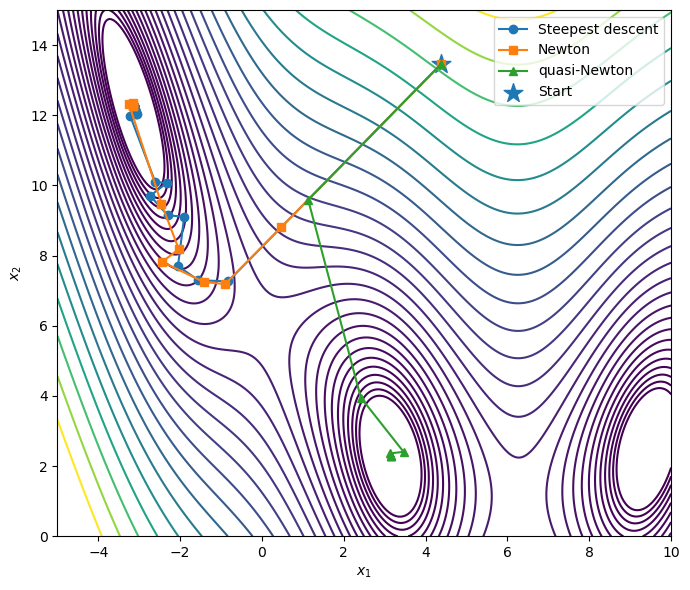

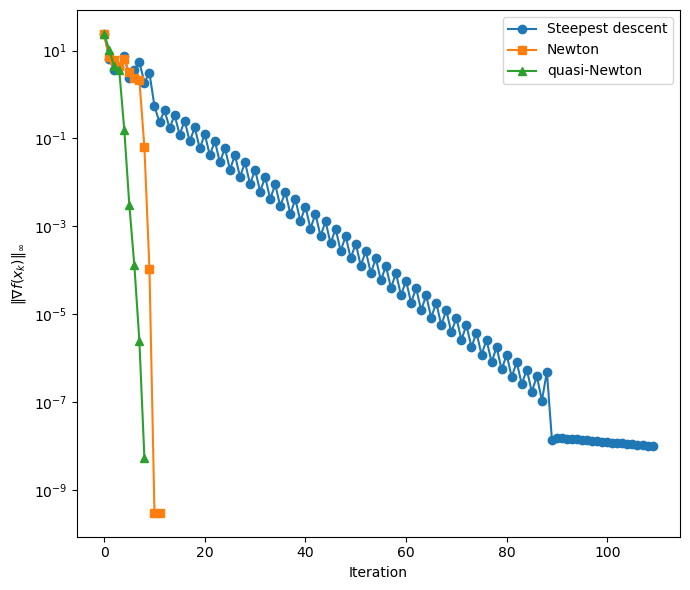

In [9]:


# ----------------------------
# Plot 1: Contours + optimization paths
# ----------------------------
x1_grid = np.linspace(-5, 10, 400)
x2_grid = np.linspace(0, 15, 400)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
Z = np.zeros_like(X1)
for i in range(Z.shape[0]):
    for j in range(Z.shape[1]):
        Z[i, j] = branin([X1[i, j], X2[i, j]])

plt.figure(figsize=(7, 6))
levels = np.geomspace(np.percentile(Z, 5), np.percentile(Z, 99), 25)
plt.contour(X1, X2, Z, levels=levels)
plt.plot(xs_gd[:, 0], xs_gd[:, 1], marker="o", linewidth=1.5, label="Steepest descent")
plt.plot(xs_nt[:, 0], xs_nt[:, 1], marker="s", linewidth=1.5, label="Newton")
plt.plot(xs_bfgs[:, 0], xs_bfgs[:, 1], marker="^", linewidth=1.5, label="quasi-Newton")
plt.scatter([x0[0]], [x0[1]], marker="*", s=200, label="Start")
plt.xlim(-5, 10)
plt.ylim(0, 15)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
# plt.title("Branin–Hoo: optimization paths")
plt.legend()
plt.tight_layout()
plt.savefig("branin_path.png")
plt.show()


# ----------------------------
# Plot 2: Convergence of ||grad||_inf
# ----------------------------
plt.figure(figsize=(7, 6))
plt.semilogy(np.arange(len(ginf_gd)), ginf_gd, marker="o", linewidth=1.5, label="Steepest descent")
plt.semilogy(np.arange(len(ginf_nt)), ginf_nt, marker="s", linewidth=1.5, label="Newton")
plt.semilogy(np.arange(len(ginf_bfgs)), ginf_bfgs, marker="^", linewidth=1.5, label="quasi-Newton")
plt.xlabel("Iteration")
plt.ylabel(r"$\|\nabla f(x_k)\|_{\infty}$")
# plt.title("Convergence (gradient infinity norm)")
plt.legend()
plt.tight_layout()
plt.savefig("branin_history.png")
plt.show()

